# Boosted Decision Tree Skeleton


In this cell, split the dataset into _train_ and _test_ samples, using sci-kit learn `train_test_split()`.


In [21]:
import sys
sys.path.append("/users/xn22103/atmospherics-tools/fast-osc-feedback/")

import polars as pl
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]

Enu_e_had   = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
Enu_e_calo  = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
Enu_mu_had  = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
Enu_mu_range= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"
PDG         = "rec/mc/mc.nu/mc.nu.pdg"

caf_data = caf_tree.arrays([Enu_e_had, Enu_e_calo, Enu_mu_had, Enu_mu_range, PDG])

caf_df = pl.from_pandas(ak.to_dataframe(caf_data, how = "outer"))
caf_df.columns = ["Enu_e_had","Enu_e_calo","Enu_mu_had","Enu_mu_range","PDG"]

reco_pfp_tree = uproot.open("reco_pfp_info.root")["reco_pfp_tree"]
reco_pfp_df = pl.from_pandas(reco_pfp_tree.arrays(library="pd"))

data = pl.concat([caf_df, reco_pfp_df], how="horizontal")

data = data.filter(pl.col("reco_ok") == True)


data = data.with_columns(
	(1 - (pl.col("Enu_e_had") / pl.col("Enu_e_calo"))).alias("inelasticity_e"),
	(1 - (pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))).alias("inelasticity_mu"),
	(pl.col("PDG") < 0).cast(pl.Int64).alias("label"))



data = data.to_pandas()
data = data.dropna()
data

,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,PDG,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,inelasticity_e,inelasticity_mu,label
0,1.237640e+01,28.432413,28.015844,28.529816,-12,True,10,5,4,11.487990,4,1,0.564708,0.018015,1
1,9.994991e-02,0.208079,0.099950,0.322256,-12,True,2,1,0,0.110940,1,0,0.519653,0.689843,1
2,3.063447e-01,1.156426,0.306345,1.201710,-14,True,4,3,0,0.064570,2,1,0.735094,0.745076,1
3,8.884442e-02,0.502835,0.088844,0.593700,14,True,3,2,0,0.002420,1,1,0.823313,0.850355,0
4,3.318707e-03,0.299485,0.003319,0.299201,16,True,2,1,0,0.003319,1,0,0.988919,0.988908,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2651022,-8.104407e-17,0.156685,0.000000,0.256748,14,True,2,1,0,0.000000,1,0,1.000000,1.000000,0
2651023,2.552473e-03,0.169946,0.002552,0.260973,14,True,2,1,0,0.005397,1,0,0.984981,0.990219,0
2651024,1.402719e-02,0.124140,0.014027,0.207403,14,True,3,1,1,0.012165,1,0,0.887005,0.932367,0
2651025,5.641751e-02,1.383207,1.343197,1.471067,12,True,3,1,1,0.102556,0,1,0.959213,0.086923,0


In [22]:
# code to set only the inelasticity of the correct neutrino type to non zero for each event

import numpy as np

data["inelasticity"] = np.select([data["PDG"].abs() == 14,data["PDG"].abs() == 12,],[data["inelasticity_mu"],data["inelasticity_e"],],default=np.nan)

data = data.drop(columns=["inelasticity_e", "inelasticity_mu"])

data


,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,PDG,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,label,inelasticity
0,1.237640e+01,28.432413,28.015844,28.529816,-12,True,10,5,4,11.487990,4,1,1,0.564708
1,9.994991e-02,0.208079,0.099950,0.322256,-12,True,2,1,0,0.110940,1,0,1,0.519653
2,3.063447e-01,1.156426,0.306345,1.201710,-14,True,4,3,0,0.064570,2,1,1,0.745076
3,8.884442e-02,0.502835,0.088844,0.593700,14,True,3,2,0,0.002420,1,1,0,0.850355
4,3.318707e-03,0.299485,0.003319,0.299201,16,True,2,1,0,0.003319,1,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2651022,-8.104407e-17,0.156685,0.000000,0.256748,14,True,2,1,0,0.000000,1,0,0,1.000000
2651023,2.552473e-03,0.169946,0.002552,0.260973,14,True,2,1,0,0.005397,1,0,0,0.990219
2651024,1.402719e-02,0.124140,0.014027,0.207403,14,True,3,1,1,0.012165,1,0,0,0.932367
2651025,5.641751e-02,1.383207,1.343197,1.471067,12,True,3,1,1,0.102556,0,1,0,0.959213


In [23]:
import pandas as pd

consistency = pd.crosstab(data['PDG'] < 0, data['label'])
consistency.index = ['PDG > 0 (Nu)', 'PDG < 0 (Anti-Nu)']
consistency.columns = ['Label 0', 'Label 1']
print(consistency)

                   Label 0  Label 1
PDG > 0 (Nu)       1981454        0
PDG < 0 (Anti-Nu)        0   669573


In [24]:
electron_mask = data['PDG'].abs() == 12
muon_mask = data['PDG'].abs() == 14
tau_mask = data['PDG'].abs() == 16


electron_data = data[electron_mask]
muon_data = data[muon_mask] 
tau_data = data[tau_mask]


In [25]:

feature_columns = ['inelasticity', 'n_reco_pfps', 'n_reco_tracks', 'n_reco_showers', 'single_hits_energy', 'n_reco_muons_pions', 'n_reco_protons']
data = data.dropna()

# for col in [
# 	"single_hits_energy",
# 	"n_reco_pfps",
# 	"n_reco_tracks",
# 	"n_reco_showers",
# 	"n_reco_protons",
# ]:
# 	data[col] = np.log1p(data[col])


X_data = muon_data[feature_columns].values


y_data = muon_data['label']

muon_data[feature_columns]

,inelasticity,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons
2,0.745076,4,3,0,0.064570,2,1
3,0.850355,3,2,0,0.002420,1,1
7,0.300109,10,6,3,0.445253,5,1
10,0.899337,2,1,0,0.019301,0,1
16,0.327357,8,6,1,0.108775,5,1
...,...,...,...,...,...,...,...
2651021,0.507993,4,2,1,0.164924,1,1
2651022,1.000000,2,1,0,0.000000,1,0
2651023,0.990219,2,1,0,0.005397,1,0
2651024,0.932367,3,1,1,0.012165,1,0


In [26]:
print(np.unique(y_data, return_counts=True))


(array([0, 1]), array([805723, 264056]))


In [27]:

# # plt.rcParams['agg.path.chunksize'] = 10000
# plt.plot(data['inelasticity_e'], data['PDG'])
# plt.show()


In [28]:
# plt.plot(data['inelasticity_mu'], data['PDG'])

In [29]:
from sklearn.model_selection import train_test_split

# split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.33, random_state=42)

Train the BDT using the `GradientBoostingClassifier` from sci-kit learn.  Note that `HistGradientBoostingClassifier` is also available, and should be more computationally efficient on large samples (>10k).

In [30]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
clf = HistGradientBoostingClassifier(
	learning_rate=0.05,
	max_depth=None,
    max_leaf_nodes=31,
	min_samples_leaf=50,
	max_iter=2000,
	class_weight="balanced",
	early_stopping=True,
	# validation_fraction=0.2,
	# n_iter_no_change=30,
	random_state=0
).fit(X_train, y_train)

Now generate predictions (i.e. log-odds probabilities for each event) for both the test and train samples.

In [31]:

# create the result for train datasest
scores_train = clf.decision_function(X_train)

# create the results for test dataset
scores_test = clf.decision_function(X_test)

In [32]:
n_index = 0 
an_index = 1

print(np.unique(y_test, return_counts=True))



(array([0, 1]), array([266104,  86924]))


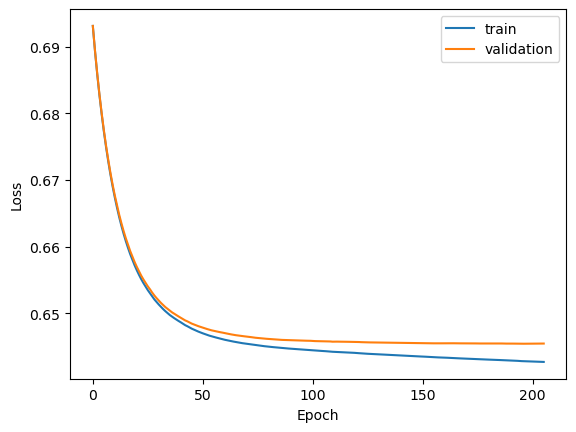

In [33]:
train_loss = [-s for s in clf.train_score_]
val_loss   = [-s for s in clf.validation_score_]

plt.plot(train_loss, label="train")
plt.plot(val_loss, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


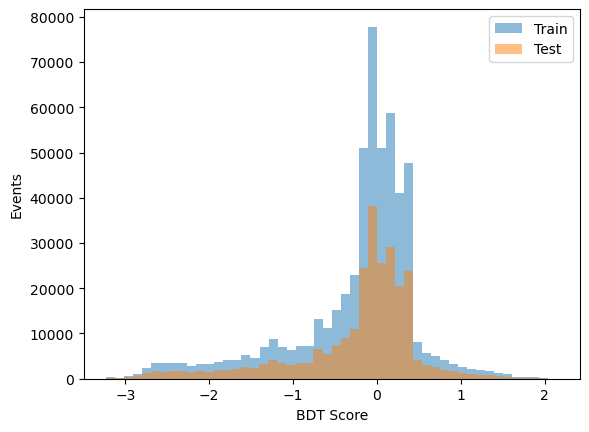

In [34]:
plt.hist(clf.decision_function(X_train[y_train==0]), bins=50, alpha=0.5, label="Train")
plt.hist(clf.decision_function(X_test[y_test==0]), bins=50, alpha=0.5, label="Test")

plt.ylabel("Events")
plt.xlabel("BDT Score")
plt.legend()

Text(0, 0.5, 'Events')

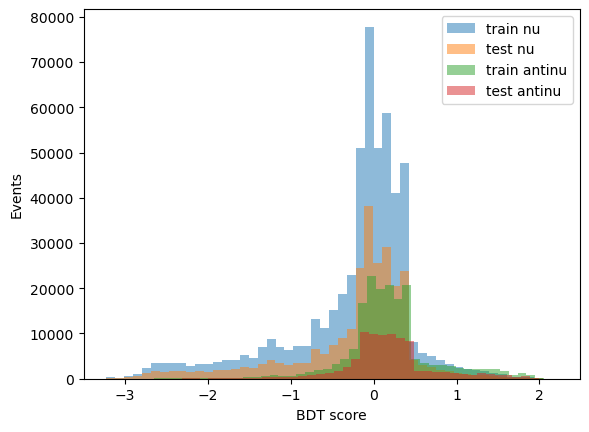

In [35]:
plt.hist(clf.decision_function(X_train[y_train==0]), bins=50, alpha=0.5, label="train nu")
plt.hist(clf.decision_function(X_test[y_test==0]), bins=50, alpha=0.5, label="test nu")

plt.hist(clf.decision_function(X_train[y_train==1]), bins=50, alpha=0.5, label="train antinu")
plt.hist(clf.decision_function(X_test[y_test==1]), bins=50, alpha=0.5, label="test antinu")

plt.legend()
plt.xlabel("BDT score")
plt.ylabel("Events")


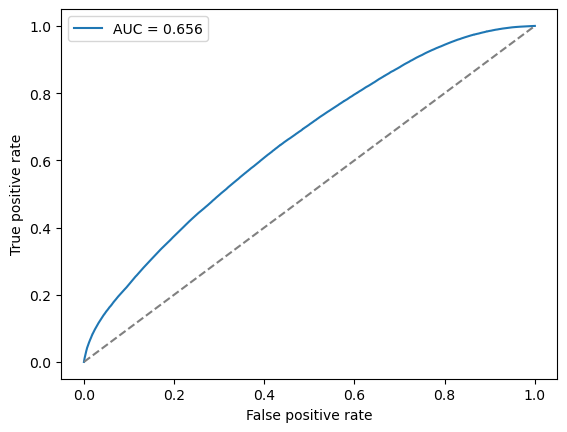

In [36]:
from sklearn.metrics import roc_curve, auc

probs = clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.show()


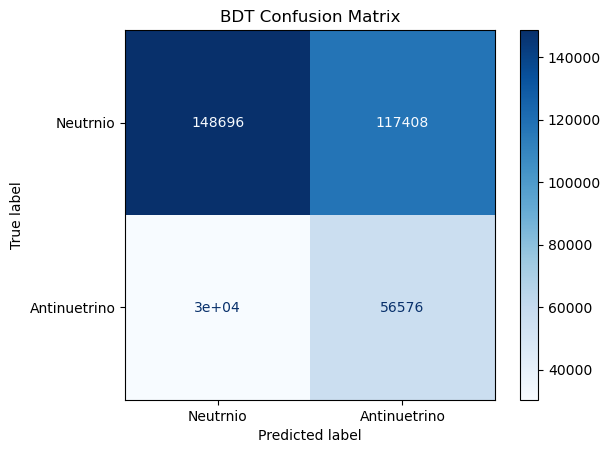

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutrnio', 'Antinuetrino'])
disp.plot(cmap=plt.cm.Blues)
plt.title("BDT Confusion Matrix")
plt.show()

In [38]:
from sklearn.inspection import permutation_importance

r = permutation_importance(clf, X_data, y_data, n_repeats=5)


In [39]:
for name, val in zip(feature_columns, r["importances_mean"]):
	print(name, val)

inelasticity 0.016074535020784708
n_reco_pfps 0.031613445393861773
n_reco_tracks 0.04099108320503586
n_reco_showers 0.006728118611414158
single_hits_energy 0.04593846018663672
n_reco_muons_pions -0.023565241045113018
n_reco_protons -0.0025216423205166373


In [41]:
from sklearn.metrics import log_loss

x = log_loss(y_true=y_test, y_pred=probs)
print(x)

0.6473476389988557


In [42]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Neutrino', 'Antineutrino']))

              precision    recall  f1-score   support

    Neutrino       0.83      0.56      0.67    266104
Antineutrino       0.33      0.65      0.43     86924

    accuracy                           0.58    353028
   macro avg       0.58      0.60      0.55    353028
weighted avg       0.71      0.58      0.61    353028

